# Notebook For Figure S7 Method Paper

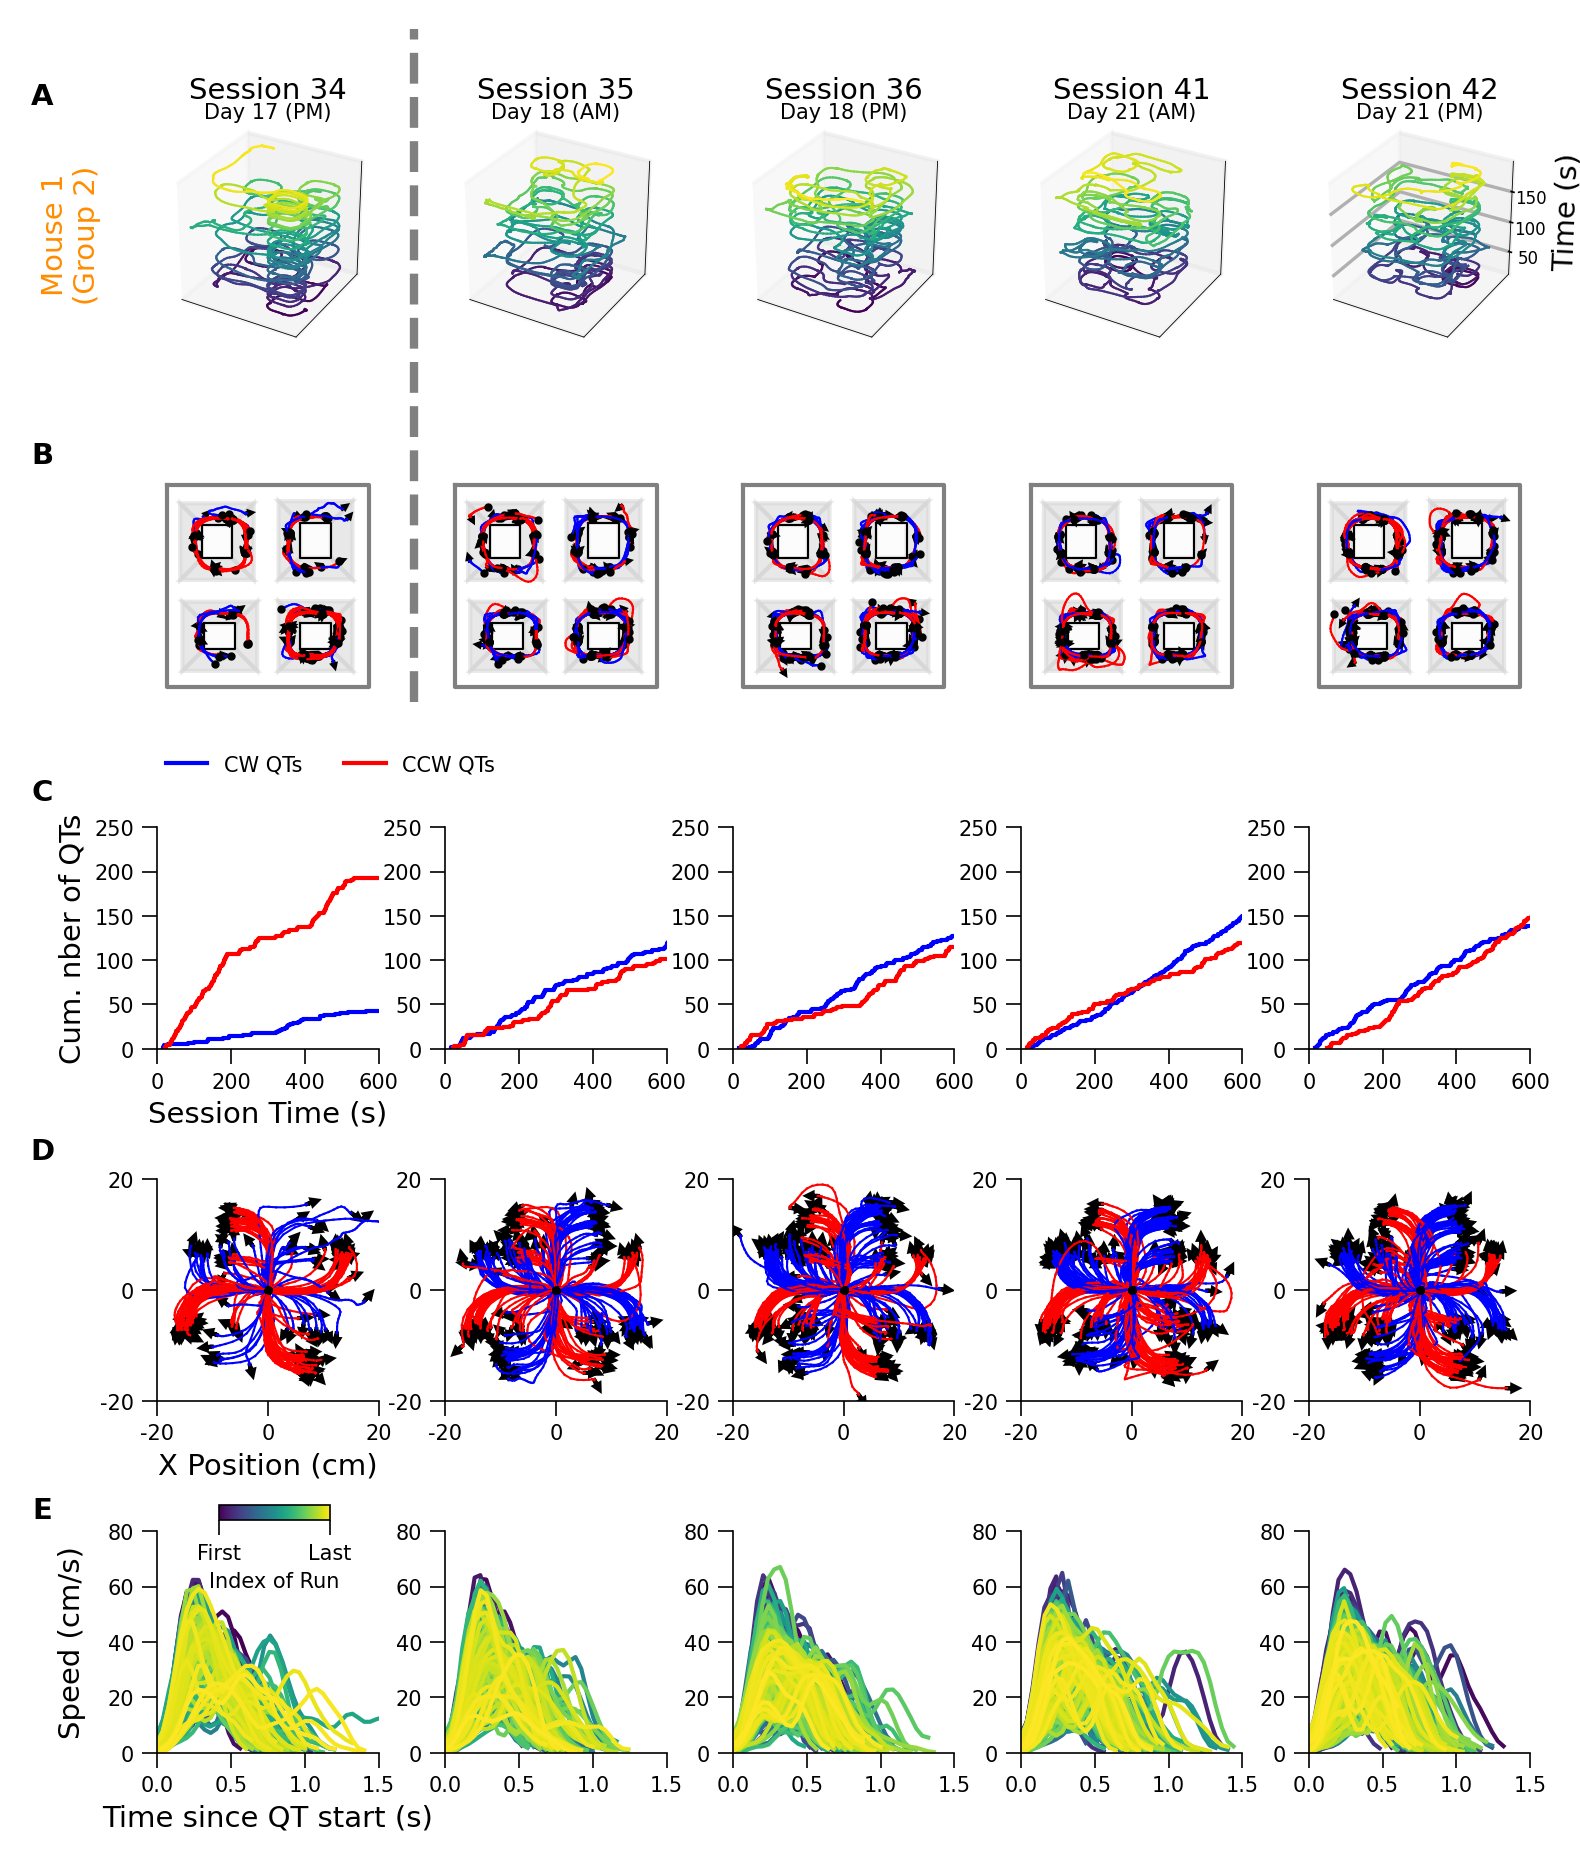

In [43]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS12.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [21]:
import os
import glob
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
from scipy.ndimage import gaussian_filter as smooth

import warnings 

plt.style.use('paper.mplstyle')


In [22]:
plotintermediatesteps = False 

# 2. Select the folder where mice data is stored

In [23]:
# Defining data folder path
# path_to_data_folder is the path of the folder where you store the folders of your different mice.
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data'
path_to_data_folder = '/home/tom/Code/tower_foraging_park_data/Group2Data'

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/MaudData/'
# path_to_data_folder = '/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'


# 3. Choosing mouse to analyse 

In [24]:
# Mouse from which data will be used to generate the plot 
example_mouse = 'MOU3974'


# 4. General functions

In [25]:
def get_day_and_period(session_idx):
    day = session_idx // 2 + 1
    period = 'AM' if session_idx % 2 == 0 else 'PM'
    return day, period

def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)


In [26]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54


In [27]:
def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []

    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def compute_average_direction(points):

    """
    Compute the average direction of a trajectory portion, assuming the coordinates are in chronological order.

    Arguments:
        points (2D numpy.array): Trajectory of which the average direction will be computed

    Outputs:
        avg_diff (1D numpy.array): vector pointing to the average direction
        angle (float): angle of the vector with the x-axis 
    """
    
    diffs = np.diff(points, axis=0)
    avg_diff = np.mean(diffs, axis=0)
    angle = np.arctan2(avg_diff[1], avg_diff[0])
    return avg_diff, angle


# 5. Panel A

### Exctract the sessions of the example mouse

In [28]:
# Define the path to the example mouse's data
folder_path_mouse_to_analyse=os.path.join(path_to_data_folder,example_mouse)

# Setting the path to the example mouse's data folder
folder_path_mouse_to_analyse=os.path.join(path_to_data_folder,example_mouse)

# Find every sessions of the example mouse
sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                and name.startswith('MOU')])


In [29]:
# Chose the sessions from which trajectory, speed and cumulative number of runs around towers will be plotted
illustration_sessions_indexes = [33, 34, 35, 40, 41]


In [30]:
# Define the arena corners coordinates
arena_coordinates_cm = [[4.5, 88.86], [90.3, 88.86], [90.3, 2.7], [4.5, 2.7]]


### Those functions are used to produce a 3D plot of chunks of trajectory for several illustrative sessions of an illustrative mouse  

In [31]:
def plot_3d_trajectory(x_coordinates, y_coordinates, times_videoframes, time_start=None, time_end=None, ax=None, linewidth=1, show_zticks_info=None):
    
    """
    #plot_3d_trajectory(x, y, t, time_start=None, time_end=None, ax=None, linewidth=1):
    Plots a 3D trajectory with (x, y) coordinates and time t as the z-axis.
    The color of the trajectory changes gradually from start to end.

    Arguments:
        x_coordinates (list): Trajectory's x coordinates
        y_coordinates (list): Trajectory's y coordinates
        times_videoframes (list): Trajectory's time
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        ax (matplotlib.axes.Axes, optional): 3D subplot axis (from plt.Axes). If None, a new axis will be created.
        linewidth (float, optional): Thickness of trajectories lines.
        show_zticks_info (bool, optional): Show the z-axis ticks if True.
    """
    
    # Create a new figure and axis if no axis is provided
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

    # Chosing session's period to analyse
    if time_start is None:
        time_start = times_videoframes[0]
    if time_end is None:
        time_end = times_videoframes[-1]

    start_idx = np.searchsorted(times_videoframes, time_start)
    end_idx = np.searchsorted(times_videoframes, time_end)

    # Extract data from the selected period
    selected_x = x_coordinates[start_idx:end_idx] # x_coordinates coordinates
    selected_y = y_coordinates[start_idx:end_idx] # y coordinates
    selected_t = times_videoframes[start_idx:end_idx] # time of points
    
    # Normalize the time for color mapping
    norm = plt.Normalize(selected_t.min(), selected_t.max())
    colors = cm.viridis(norm(selected_t))

    # Plot 3D line with gradient color
    for i in range(len(selected_x) - 1):
        ax.plot(selected_x[i:i+2], selected_y[i:i+2], selected_t[i:i+2], color=colors[i], linewidth=linewidth)

    # Hide z label, ticks, and tick labels for all axes
    ax.set_xticks([])
    ax.set_yticks([])
    if not(show_zticks_info) :
        ax.set_zticks([])
    else:
        ax.tick_params(axis='z', pad=-5,labelsize=4)
        ax.set_zlabel("Time (s)", labelpad=-12, rotation='vertical')

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.line.set_linewidth(0.2)

    
def plot_3dtrajectory_mice_sessions(illustration_mouse_name, sessions_indexes_to_plot, path_to_data_folder, time_start=None, time_end=None, axs=None,
                                    linewidth=1,show_last_zticks_info=False):
    
    """
    Uses plot_3d_trajectory to plots a 3D trajectory for all the selected sessions.
    The color of the trajectory changes gradually from start to end.

    Arguments:
        illustration_mouse_name (list of strings): list of the mice's name
        sessions_indexes_to_plot (list of int): indexes of session's of which the trajectory will be plotted
        path_to_data_folder (string or path): path of the folder where you store your the folders of your different mice
        time_start (int, optional): Time of the at which the trajectory will start being displayed
        time_end (int, optional): Time of the at which the trajectory will stop being displayed
        axs (list of matplotlib.axes.Axes, optional): list of ax objects in which to plot the trajectories
        linewidth (float, optional): Thickness of trajectories lines
        show_last_zticks_info (bool, optional): If True, shows the z-axis ticks on the last plot
    """

    # Number of session
    num_sessions = len(sessions_indexes_to_plot)
    
    # Ensure axs is 2D array, even if there is only one row or column
    if num_sessions == 1:
        axs = np.expand_dims(axs, axis=1)

    # Iterate through each mouse
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, illustration_mouse_name)

    # Get the list of sessions for the current mouse
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # Iterate through each session for the current mouse
    for session_idx, session_to_plot_index in enumerate(sessions_indexes_to_plot):
        session_to_plot = sessions_to_analyse[session_to_plot_index]

        # Define the pickle file path
        output_pickle_filename = f"{session_to_plot}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_plot, output_pickle_filename)
            
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_plot}, skipping .....')
            continue
            
        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)
            
        # Get the positions
        positions = np.array(session_data['positions'])
        timeofframes=session_data['timeofframes']

        # Plot the trajectory on the respective subplot
        if show_last_zticks_info and session_idx == len(axs)-1:
            plot_3d_trajectory(positions[0, :], positions[1, :], timeofframes, ax=axs[session_idx], time_start=time_start, time_end=time_end, linewidth=linewidth,
                               show_zticks_info=True)
        else:
            plot_3d_trajectory(positions[0, :], positions[1, :], timeofframes, ax=axs[session_idx], time_start=time_start, time_end=time_end, linewidth=linewidth,
                               show_zticks_info=False)


# Plot panel A

In [32]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(12), cm2inch(9)), dpi=300, constrained_layout=False, facecolor='w')

    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel A ###

    row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
    
    ax_1_list = []

    for i in range(len(illustration_sessions_indexes)):
    
        ax_1_list.append(plt.subplot(row1[i], projection="3d", aspect="equal"))
    
        ax_1_list[i].text2D(0.5, 1.1, f'Session {illustration_sessions_indexes[i]+1}', va='center', ha='center', transform=ax_1_list[i].transAxes, fontsize=7)
        
        if i==0:
            
            ax_1_list[i].text2D(-0.1, 0.5, 'Mouse 1', color='darkorange',rotation=90, va='center', ha='center', transform=ax_1_list[i].transAxes, fontsize=7)

    plot_3dtrajectory_mice_sessions(example_mouse, illustration_sessions_indexes, path_to_data_folder, axs=ax_1_list, linewidth=0.5, show_last_zticks_info=True)
        # Define vertical line in figure coordinates
    x_fig = 0.2      # horizontal position (from 0 to 1 across the figure)
    y0 = 0.71        # bottom of the line (figure coordinate)
    y1 = 0.87        # top of the line (figure coordinate)

    line = plt.Line2D([x_fig, x_fig], [y0, y1], transform=fig.transFigure,
                    color='grey', linewidth=2,linestyle='--')
    
    fig.add_artist(line)


# 6. Panel B

In [33]:
def plot_run_type(folder_path_mouse_to_analyse, session_to_analyse, arena_coordinates, ax, runtype='', q=4, time_start=None, time_end=None):
    
    """
    Plots trajectories of the selected run types.
    
    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_to_analyse (str): Name of the session to analyse.
        arena_coordinates (list): List of four 2D coordinates, locating the corners of the arena.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        runtype (str): name of the type of run to plot. Choose among: "run_around_tower", "run_between_towers", "run_toward_tower", "exploratory_run", "immobility", "unclassified"
        q (int, optional): Number of points used to determine movement direction to plot arrows. Default is 4.
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
    
    """
    
    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time data for the trajectory
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed X and Y positions of the mouse
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Extract epoch data and trapeze coordinates
    all_epochs = session_data['all_epochs']
    all_trapezes_coordinates_cm = session_data['all_trapezes_coordinates_cm']

    # If runtype is not provided, raise a warning and return
    if not runtype:
        warnings.warn("The 'runtype' parameter is required and was not provided.")
        return
    
    # Retrieve the epochs corresponding to the provided runtype
    runtype_epochs = filter_qts(all_epochs.get(runtype)) if runtype=='run_around_tower' else all_epochs.get(runtype)
    
    # If no epochs are found for the provided runtype, raise a warning and return
    if runtype_epochs is None:
        warnings.warn(f"The 'runtype' '{runtype}' is not found in 'all_epochs'.")
        return
    
    tower_coordinates = session_data['towers_coordinates_cm']
    
    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, 'black', alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)

    # Plot each trapeze
    fill_colors = ['lightgray'] * 4  # Use a list of light blue colors for trapezes
    
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates_cm.items()):
        for j, (trapeze, coordinates) in enumerate(trapezes.items()):
            # Close the trapeze polygon by appending the first vertex
            coordinates_copy = coordinates + [coordinates[0]]
            x_coords, y_coords = zip(*coordinates_copy)
            
            # Fill the trapeze area with the color
            ax.fill(x_coords, y_coords, color=fill_colors[j % len(fill_colors)], alpha=0.5)

    # Loop through each epoch in the runtype and plot the trajectory
    for runtype_epoch in runtype_epochs:
        # Get the start and end indices of the current epoch
        start_index, end_index = runtype_epoch[0][0], runtype_epoch[0][1]

        # Skip the epoch if it is outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Check that the start and end indices are within the bounds of the trajectory time array
        if start_index < 0 or end_index >= len(traject_time):
            print(f"Indexes out of bounds for runtype_epoch: {runtype_epoch}")
            continue

        # Extract the positions for the current epoch
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        
        numberofpositions = len(runtype_epoch_Xpositions)

        # Ensure that the lengths of X and Y positions match
        if len(runtype_epoch_Xpositions) != len(runtype_epoch_Ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")

        # Loop through the positions to plot the trajectory
        for index in range(numberofpositions - 2):
            # Use a different color for run_around_tower if the direction matches the rewarded direction
            if runtype == 'run_around_tower':
                color = 'blue' if runtype_epoch[3]['direction'] == 'CW' else 'red'
            else:
                color = 'black'
            
            # Plot the line segment between consecutive positions
            ax.plot(runtype_epoch_Xpositions[index:index + 2], runtype_epoch_Ypositions[index:index + 2], color=color, linewidth=0.5)
                
        # Plot the start point as a small black circle
        ax.plot(runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0], color='black', marker='o', markersize=1)

        # Compute the direction of the arrow using the last 'q' positions (default is 4)
        if len(runtype_epoch_Xpositions) >= q:
            dx = runtype_epoch_Xpositions[-1] - runtype_epoch_Xpositions[-q]
            dy = runtype_epoch_Ypositions[-1] - runtype_epoch_Ypositions[-q]
            
            # Normalize the direction vector
            norm = np.hypot(dx, dy)
            if norm != 0:
                dx /= norm
                dy /= norm
            
            # Plot the direction arrow at the end point
            ax.arrow(runtype_epoch_Xpositions[-1], runtype_epoch_Ypositions[-1], dx, dy,
                      head_width=1, head_length=1, fc='black', ec='black')
    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)
    
    # Hide the spines (axes) from the plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove the ticks from the x and y axes
    ax.set_xticks([])
    ax.set_yticks([])


# Plot panel B

In [34]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel B ###

    row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
    
    for j in range(len(illustration_sessions_indexes)):

        ax_1 = plt.subplot(row1[j], aspect="equal")
        
        plot_run_type(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[j]],
                      arena_coordinates_cm, ax_1, runtype='run_around_tower', q=4)


# 7. Panel C

In [35]:
def plot_runs_around_towers_origin(folder_path_mouse_to_analyse, session_to_analyse, ax, q=4, time_start=None, time_end=None, show_legend=True, xlim=None,
                                   ylim=None, show_xlabel=True, show_ylabel=True):
    """
    Plots the trajectory of the "run around tower" epochs, with the origin of each run aligned to its start position. 
    The plot also displays the direction of movement and optionally includes a legend, axis labels, and axis limits.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing the session's data.
        session_to_analyse (str): Name of the session to analyse.
        ax (matplotlib.axes.Axes): The axis object where the plot will be drawn.
        q (int, optional): Number of previous points used to compute the direction arrow. Defaults to 4.
        time_start (float, optional): The start time for plotting. Defaults to the first time in the data.
        time_end (float, optional): The end time for plotting. Defaults to the last time in the data.
        show_legend (bool, optional): Whether to show the legend indicating rewarded and unrewarded directions. Defaults to True.
        xlim (tuple, optional): Limits for the x-axis.
        ylim (tuple, optional): Limits for the y-axis.
        show_xlabel (bool, optional): Whether to show the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to show the y-axis label. Defaults to True.

    """
    
    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the trajectory time information
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed positions (X and Y) from the session data
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Retrieve the epochs corresponding to 'run_around_tower'
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))
    
    # Define the fixed origin at (0, 0)
    fixed_origin = (0, 0) 
    labels_displayed = set()  # Set to track displayed labels for direction types (rewarded/unrewarded)
    
    # Loop through each 'run_around_tower' epoch to plot the trajectory
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip epochs that fall outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the X and Y positions for the current run
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        numberofpositions = len(runtype_epoch_Xpositions)
        
        # Determine the start position and translate the coordinates to have this as the origin
        start_x, start_y = runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0]
        translated_Xpositions = [x - start_x + fixed_origin[0] for x in runtype_epoch_Xpositions]
        translated_Ypositions = [y - start_y + fixed_origin[1] for y in runtype_epoch_Ypositions]

        # Loop through positions and plot the trajectory between consecutive points
        for i in range(numberofpositions - 1):
            # Choose color based on direction (rewarded vs. unrewarded)
            color = 'blue' if run_around_tower[3]['direction'] == 'CW' else 'red'            

            # Label the lines for first occurrence of each color (rewarded/unrewarded)
            if color == 'blue' and not('blue' in labels_displayed):
                line_label = 'CW direction'
                labels_displayed.add('blue')
            elif color == 'red' and not('red' in labels_displayed):
                line_label = 'CCW direction'
                labels_displayed.add('red')
            else:
                line_label = ''
            
            # Plot the trajectory between two consecutive points
            ax.plot(translated_Xpositions[i:i+2], translated_Ypositions[i:i+2], color=color, linewidth=0.5, label=line_label)

        # Plot the start point as a black marker
        ax.plot(translated_Xpositions[0], translated_Ypositions[0], marker='o', color='black', linewidth=0.5, markersize=1)

        # Compute and plot an arrow showing the direction of movement based on the last 'q' points
        if len(translated_Xpositions) >= q:
            dx = translated_Xpositions[-1] - translated_Xpositions[-q]
            dy = translated_Ypositions[-1] - translated_Ypositions[-q]
            norm_speed = np.hypot(dx, dy)
            if norm_speed != 0:
                dx /= norm_speed
                dy /= norm_speed
            # Plot the arrow in red to indicate movement direction
            ax.arrow(translated_Xpositions[-1], translated_Ypositions[-1], dx, dy, head_width=1, head_length=1, fc='black', ec='black')

    # Set the x-axis label if specified
    if show_xlabel:
        ax.set_xlabel('X Position (cm)')
    
    # Set the y-axis label if specified
    if show_ylabel:
        ax.set_ylabel('Y Position (cm)')

    # Set the limits for the x and y axes if provided
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Hide the top and right spines for better aesthetics
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Show the legend if specified
    if show_legend:
        ax.legend(loc=[0.4, 1.2], frameon=False)


# Plot panel C

In [36]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel C ###

    row2 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

    for k in range(len(illustration_sessions_indexes)):

        ax_2 = plt.subplot(row2[k], aspect="equal")
        
        plot_runs_around_towers_origin(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[k]], ax_2, q=4,
                                       show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= True if k==0 else False,
                                       xlim=(-30,30), ylim=(-30,30))
        ax_2.set_xticks([-20, 0, 20])
        ax_2.set_yticks([-20, 0, 20])


# 8. Panel D

In [37]:
def plot_runs_around_speed_profiles(folder_path_mouse_to_analyse, session_to_analyse, ax, time_start=None, time_end=None, xlim=None, ylim=None, show_xlabel=True,
                                    show_ylabel=True, show_color_bar=True, colorbar_position=[0.25, 0.8, 0.5, 0.07]):
    """
    This function plots the speed profiles of "runs around tower" epochs from a session's data.
    
    Arguments:
        folder_path_mouse_to_analyse (str): The directory path containing the session's data.
        session_to_analyse (str): The name of the session to analyse.
        ax (matplotlib.axes.Axes): The axis object where the plot will be drawn.
        time_start (float, optional): The start time for the plot. Defaults to the first time point.
        time_end (float, optional): The end time for the plot. Defaults to the last time point.
        xlim (tuple, optional): Limits for the x-axis.
        ylim (tuple, optional): Limits for the y-axis.
        show_xlabel (bool, optional): Whether to show the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to show the y-axis label. Defaults to True.
        show_color_bar (bool, optional): Whether to display a color bar. Defaults to True.
        colorbar_position (list): Position and size of the color bar [x, y, width, height].
    
    """
    
    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the trajectory time information
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed positions (X and Y) and speed data from session
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]
    speeds = session_data['speeds']

    # Retrieve the epochs corresponding to 'run_around_tower'
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Initialize a counter for the total number of runs within the specified time window
    n_total = 0

    # Loop through each 'run_around_tower' epoch and count how many are within the time window
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]
        
        # Skip the epochs that fall outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Increment the total count of runs within the time window
        n_total += 1
    
    # Define colormap for color representation of the runs
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=n_total)  # Normalize for color mapping

    # Local index to differentiate each run in the color scale
    local_index = 0

    # Loop through the 'run_around_tower' epochs again to plot the speed profile
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip the epochs outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the positions for the current run
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]

        # Ensure that X and Y positions lists have the same length
        if len(runtype_epoch_Xpositions) != len(runtype_epoch_Ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")

        # Adjust the time to start from zero for the current run epoch
        adjusted_time = [t - traject_time[start_index] for t in traject_time[start_index:end_index + 1]]
        
        # Plot the speed for the current run
        ax.plot(adjusted_time, speeds[start_index:end_index + 1], color=cmap(norm(local_index)))
        
        # Increment the local index for color mapping
        local_index += 1 

    # Set the x-axis label if specified
    if show_xlabel:
        ax.set_xlabel('Time since QT start (s)')
    
    # Set the y-axis label if specified
    if show_ylabel:
        ax.set_ylabel('Speed (cm/s)')

    # Set the limits for the x and y axes if provided
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Add color bar if specified
    if show_color_bar:
        cbax = ax.inset_axes(colorbar_position)  # Define the position for the color bar
        cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbax, orientation='horizontal')
        cbar.set_label('Index of Run', fontsize=5)
        cbar.set_ticks([0, n_total])  # Set color bar ticks
        cbar.set_ticklabels(['First', 'Last'], fontsize=5)  # Label the ticks as First and Last


# Plot panel D

In [38]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel D ###

    row3 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)
    
    for l in range(len(illustration_sessions_indexes)):

        ax_3 = plt.subplot(row3[l], aspect="equal")

        plot_runs_around_speed_profiles(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[l]], ax_3, xlim=(0,2), ylim=(0,80),
                                        show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False,
                                        colorbar_position=[0.25, 0.9, 0.5, 0.07])
        force_aspect(ax_3,ratio=1)


# 9. Panel E

In [39]:
def plot_cumulated_turns_time_profile(folder_path_mouse_to_analyse, session_to_analyse, ax, time_start=None, time_end=None, xlim=None, ylim=None, show_xlabel=True,
                                      show_ylabel=True, show_legend=True, legend_loc=(1,1)):
    """
    This function plots the cumulative number of turns (CW vs. CCW) over time during a session.
    
    Arguments:
        folder_path_mouse_to_analyse (str): The directory where the mouse data is stored.
        session_to_analyse (str): The name of the session to analyse.
        ax (matplotlib.axes.Axes): The axes to plot the graph on.
        time_start (float, optional): The start time for the plot. Defaults to the first time frame.
        time_end (float, optional): The end time for the plot. Defaults to the last time frame.
        xlim (tuple, optional): The limits for the x-axis (time). Defaults to None, which auto-scales.
        ylim (tuple, optional): The limits for the y-axis (cumulative number of turns). Defaults to None, which auto-scales.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to display the y-axis label. Defaults to True.
        show_legend (bool, optional): Whether to display the legend. Defaults to True.
    
    """
    
    # Load the session data from a pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract trajectory time and check if the time range is provided
    traject_time = session_data['timeofframes']
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the runs around tower data
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Prepare lists for CW and CCW times
    time_of_runsaroundtower_CW = []
    time_of_runsaroundtower_CCW = []

    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Check if the current run is within the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Separate times based on direction (CW or CCW)
        if run_around_tower[3]['direction'] == 'CW':
            time_of_runsaroundtower_CW.append(run_around_tower[4]['epoch_time'])
        if run_around_tower[3]['direction'] == 'CCW':
            time_of_runsaroundtower_CCW.append(run_around_tower[4]['epoch_time'])

    # Sort CW and CCW times
    CW_times_sorted = np.sort(time_of_runsaroundtower_CW)
    CCW_times_sorted = np.sort(time_of_runsaroundtower_CCW)

    # Calculate the cumulative counts
    CW_cumulative = np.arange(1, len(CW_times_sorted) + 1)
    CCW_cumulative = np.arange(1, len(CCW_times_sorted) + 1)

    # Plot the cumulative number of good and bad turns over time
    ax.step(CW_times_sorted, CW_cumulative, where='post', label='CW QTs', color='blue')
    ax.step(CCW_times_sorted, CCW_cumulative, where='post', label='CCW QTs', color='red')
    
    # Set axis labels and limits based on user input
    if show_xlabel:
        ax.set_xlabel('Session Time (s)')
    if show_ylabel:
        ax.set_ylabel('Cum. nber of QTs')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Display the legend if requested
    if show_legend:
        ax.legend(loc=legend_loc, frameon=False,ncols=2)

    # Hide unnecessary spines for cleaner visualization
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


# Plot panel E

In [40]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel E ###

    row4 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)
    
    for m in range(len(illustration_sessions_indexes)):

        ax_4 = plt.subplot(row4[m], aspect="equal")
        
        show_xlabel= True if m==0 else False
        show_ylabel = True if m==0 else False
        xlim = [0,600]
        ylim = [0,250]

        plot_cumulated_turns_time_profile(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[m]], ax_4, xlim=xlim, ylim=ylim ,
                                          show_xlabel=show_xlabel, show_ylabel=show_ylabel, show_legend= False)
        force_aspect(ax_4,ratio=1)


# 10. Whole figure

/tmp/ipykernel_39694/2021914276.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


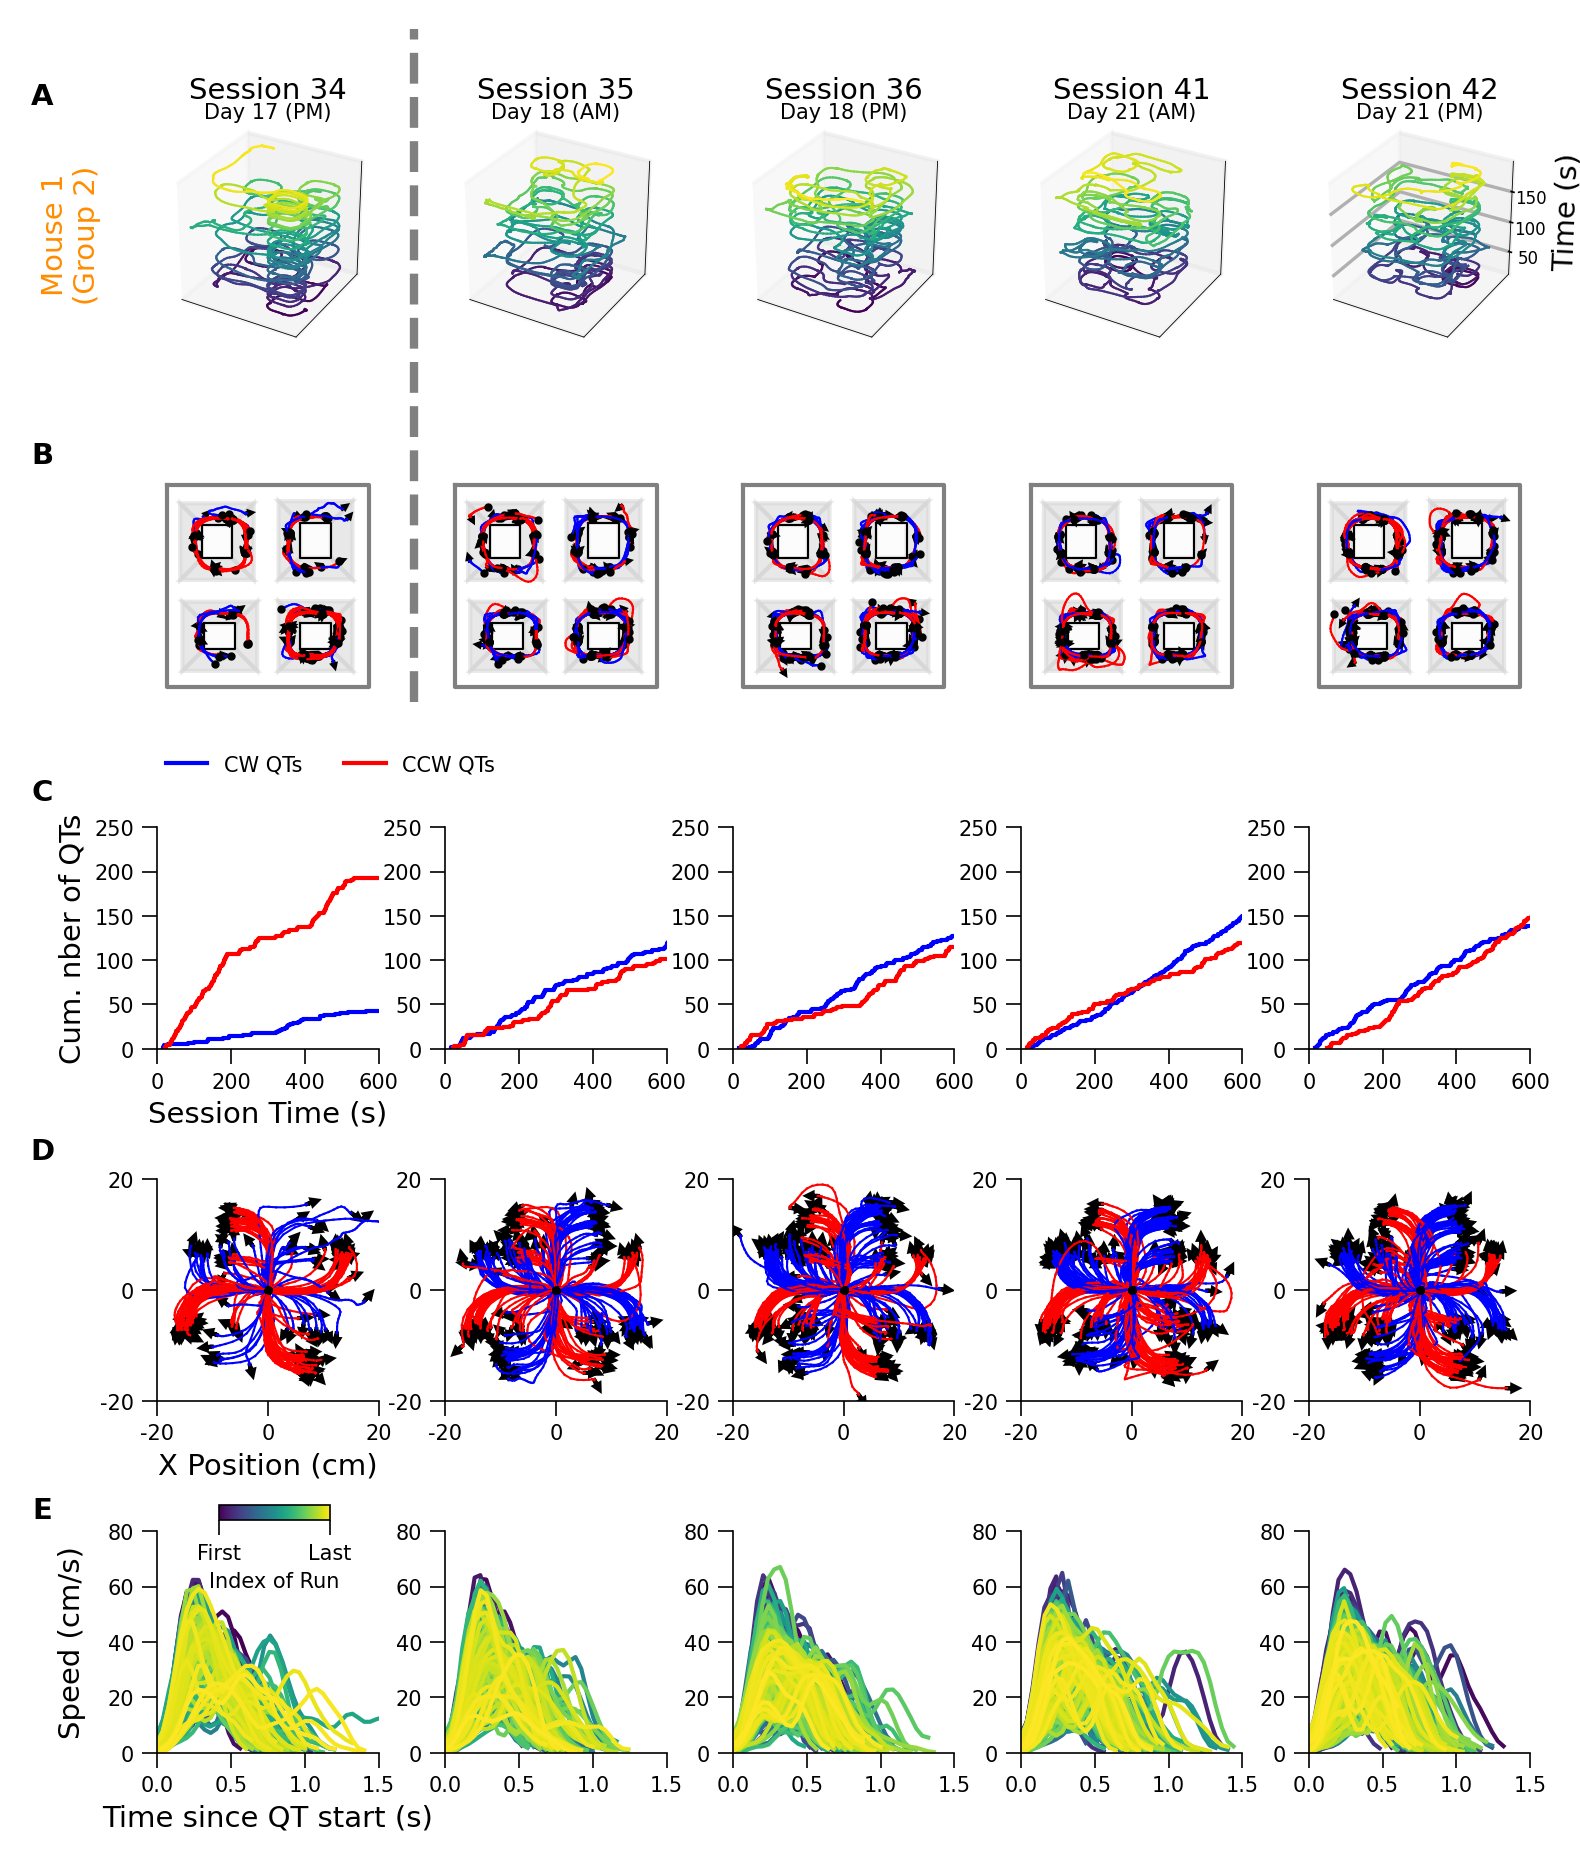

In [41]:
fig=plt.figure(figsize=(cm2inch(15), cm2inch(19)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1 , hspace=0.1)

### Panel A ###

row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
ax_1_list = []

for i in range(len(illustration_sessions_indexes)):

    ax_1_list.append(plt.subplot(row1[i], projection="3d", aspect="equal"))
    day,period=get_day_and_period(illustration_sessions_indexes[i])
    ax_1_list[i].text2D(0.5, 1.15, f'Session {illustration_sessions_indexes[i] + 1}', va='center', ha='center', transform=ax_1_list[i].transAxes, fontsize=7)
    ax_1_list[i].text2D(0.5, 1.1 - 0.05, f'Day {day} ({period})', va='center', ha='center', transform=ax_1_list[i].transAxes, fontsize=5)
    
    if i==0:
        
        ax_1_list[i].text2D(-0.39, 0.5, 'Mouse 1\n(Group 2)', color='darkorange',rotation=90, va='center', ha='center', transform=ax_1_list[i].transAxes, fontsize=7)

plot_3dtrajectory_mice_sessions(example_mouse, illustration_sessions_indexes, path_to_data_folder, axs=ax_1_list, time_start=15, time_end=195, linewidth=0.5, show_last_zticks_info=True)

fig.text(0.06, 0.87, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

row2 = gs[1].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)

for j in range(len(illustration_sessions_indexes)):
    
    ax_2 = plt.subplot(row2[j], aspect="equal")
    
    plot_run_type(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[j]], arena_coordinates_cm, ax_2, runtype='run_around_tower', q=4)
    
fig.text(0.06, 0.71, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C ###

row3 = gs[2].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)


for m in range(len(illustration_sessions_indexes)):

        ax_3 = plt.subplot(row3[m], aspect="equal")
        
        show_xlabel= True if m==0 else False
        show_ylabel = True if m==0 else False
        xlim = [0,600]
        ylim = [0,250]

        plot_cumulated_turns_time_profile(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[m]], ax_3, xlim=xlim, ylim=ylim,
                                          show_xlabel=show_xlabel, show_ylabel=show_ylabel, show_legend= True if m==0 else False, legend_loc=(0,1.2))
        force_aspect(ax_3,ratio=1)

fig.text(0.06, 0.56, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###

row4 = gs[3].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

for k in range(len(illustration_sessions_indexes)):

    ax_4 = plt.subplot(row4[k], aspect="equal")
    
    plot_runs_around_towers_origin(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[k]], ax_4, q=4,
                                   show_xlabel= True if k==0 else False, show_ylabel= False if k==0 else False, show_legend= False,
                                   xlim=(-20,20), ylim=(-20,20))
    ax_4.set_xticks([-20, 0, 20])
    ax_4.set_yticks([-20, 0, 20])

fig.text(0.06, 0.4, 'D', weight='bold', va='center', ha='center', fontsize=7)

### Panel E ###

row5 = gs[4].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

for l in range(len(illustration_sessions_indexes)):

    ax_5 = plt.subplot(row5[l], aspect="equal")

    plot_runs_around_speed_profiles(folder_path_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[l]], ax_5, xlim=(0,1.5), ylim=(0,80),
                                    show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False,
                                    colorbar_position=[0.28, 1.05, 0.5, 0.07])
    force_aspect(ax_5,ratio=1)


fig.text(0.06, 0.24, 'E', weight='bold', va='center', ha='center', fontsize=7)

fig.align_ylabels()

# Define vertical line in figure coordinates
x_fig = 0.27      # horizontal position (from 0 to 1 across the figure)
y0 = 0.6        # bottom of the line (figure coordinate)
y1 = 0.9        # top of the line (figure coordinate)

line = plt.Line2D([x_fig, x_fig], [y0, y1], transform=fig.transFigure,
                  color='grey', linewidth=2,linestyle='--')
    
fig.add_artist(line)

fig.tight_layout()
plt.savefig("FigureS12.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)


In [42]:
# Save the figure as a PDF
fig.savefig("FigureS12.pdf", format="pdf", bbox_inches='tight', dpi=300)
